# Metohd of moments 

In [1]:
from phasic import (
    Graph, with_ipv, GaussPrior, MoMResult, ProbMatchResult,
    Adam, ExpStepSize, ExpRegularization, clear_caches, dense_to_sparse,
    StateIndexer, Property, set_log_level, HalfCauchyPrior, DataPrior,  
) # ALWAYS import phasic first to set jax backend correctly
import numpy as np
import jax.numpy as jnp
import pandas as pd
from typing import Optional
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from tqdm.auto import tqdm
from vscodenb import set_vscode_theme

set_log_level('INFO')

np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

## Single parameter model

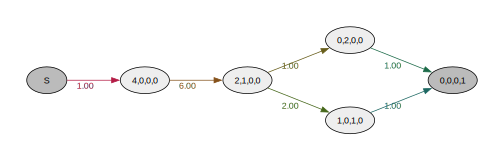

In [2]:
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent_1param)
graph.plot()

In [3]:
true_theta = [7]
graph.update_weights(true_theta)
observed_data = graph.sample(1000)

In [4]:
mom = graph.method_of_moments(observed_data)

[INFO] phasic.method_of_moments: theta_dim=1, n_free=1, nr_moments=3, n_features=1, n_equations=3
[INFO] phasic.method_of_moments: sample moments =
[[0.21236283 0.06642945 0.02821865]]
[INFO] phasic.method_of_moments: initial guess (full theta) = [6.95192796]
[INFO] phasic.method_of_moments: weighted GMM step 2 (cholesky): converged
[INFO] phasic.method_of_moments: converged — `ftol` termination condition is satisfied.
[INFO] phasic.method_of_moments: theta = [7.04278063]
[INFO] phasic.method_of_moments: residual = 1.507688e+00
[INFO] phasic.method_of_moments: model moments =
[0.21298406 0.06832333 0.03029633]


In [5]:
print(f"True theta:     {true_theta}")
print(f"MoM estimate:   {mom.theta}")
print(f"Std error:      {mom.std}")
print(f"Converged:      {mom.success}")
print(f"Residual:       {mom.residual:.2e}")

True theta:     [7]
MoM estimate:   [7.04278063]
Std error:      [0.14827141]
Converged:      True
Residual:       1.51e+00


In [6]:
print(f"Sample moments: {mom.sample_moments}")
print(f"Model moments:  {mom.model_moments}")

Sample moments: [[0.21236283 0.06642945 0.02821865]]
Model moments:  [0.21298406 0.06832333 0.03029633]


## Multi parameter model

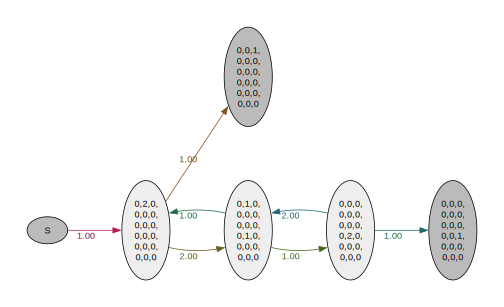

In [7]:
nr_samples = 2

indexer = StateIndexer(
    descendants=[
    Property('pop1', min_value=0, max_value=nr_samples),
    Property('pop2', min_value=0, max_value=nr_samples),
    Property('in_pop', min_value=1, max_value=2),
])

initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial)
def coalescent_islands(state):
    transitions = []
    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)
        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop:
                continue
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            des_pop1 = props_i.pop1 + props_j.pop1
            des_pop2 = props_i.pop2 + props_j.pop2
            if des_pop1 <= nr_samples and des_pop2 <= nr_samples:
                k = indexer.descendants.props_to_index(
                    pop1=des_pop1, pop2=des_pop2, in_pop=props_i.in_pop)
                child[k] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])
        if state[i] > 0:
            child = state.copy()
            other_pop = 2 if props_i.in_pop == 1 else 1
            child[i] -= 1
            k = indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=other_pop)
            child[k] += 1
            transitions.append([child, [0, state[i]]])
    return transitions

graph = Graph(coalescent_islands)
graph.plot()

In [8]:
true_theta = [0.7, 0.9]
graph.update_weights(true_theta)
observed_data = graph.sample(1000)

In [9]:
mom = graph.method_of_moments(observed_data)

[INFO] phasic.method_of_moments: theta_dim=2, n_free=2, nr_moments=2, n_features=1, n_equations=2
[INFO] phasic.method_of_moments: sample moments =
[[ 2.86113703 18.15896154]]
[INFO] phasic.method_of_moments: initial guess (full theta) = [ 0.65952441 12.37919727]
[INFO] phasic.method_of_moments: weighted GMM step 2 (cholesky): converged
[INFO] phasic.method_of_moments: converged — `gtol` termination condition is satisfied.
[INFO] phasic.method_of_moments: theta = [0.69902279 0.8006534 ]
[INFO] phasic.method_of_moments: residual = 5.990538e-20
[INFO] phasic.method_of_moments: model moments =
[ 2.86113703 18.15896154]


In [10]:
print(f"True theta:     {true_theta}")
print(f"MoM estimate:   {mom.theta}")
print(f"Std error:      {mom.std}")
print(f"Converged:      {mom.success}")

True theta:     [0.7, 0.9]
MoM estimate:   [0.69902279 0.8006534 ]
Std error:      [0.02441067 0.21783903]
Converged:      True


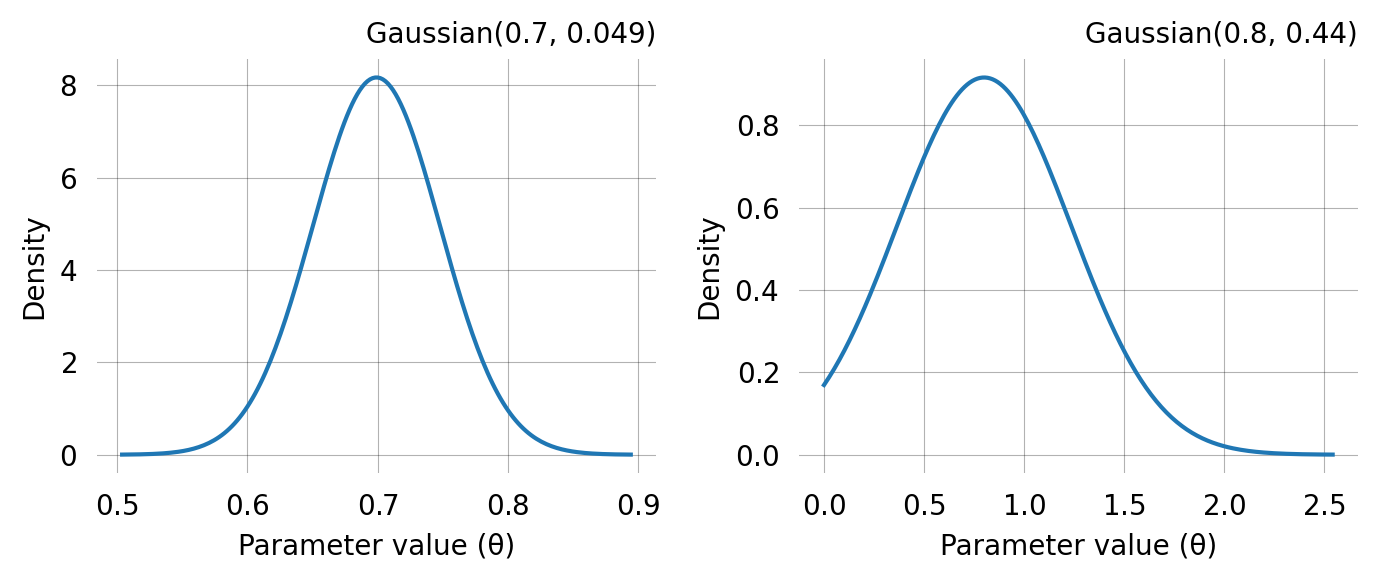

In [13]:
fig, axes = plt.subplots(1, len(mom.prior), figsize=(7,3))
for i, prior in enumerate(mom.prior):
    prior.plot(return_ax=True, ax=axes[i])
plt.tight_layout() ;

In [ ]:
svgd = graph.svgd(
    observed_data,
    prior=mom.prior,
    # optimizer=Adam(0.25),
    learning_rate=ExpStepSize(first_step=0.05, last_step=0.005, tau=20.0),
)

In [ ]:
svgd.summary()

In [ ]:
svgd.plot_convergence()

In [ ]:
svgd.plot_pairwise(true_theta=true_theta)

## Multi-feature observations with rewards

In [17]:
graph_1p = Graph(coalescent_1param)
true_theta_1p = [7]
graph_1p.update_weights(true_theta_1p)

# Create reward vectors — each row is a feature's reward across all vertices
states = graph_1p.states().T
rewards = states[:-1]  # one row per feature (e.g. singleton, doubleton, tripleton branch lengths)
print(f"Reward matrix shape: {rewards.shape}  (n_features={rewards.shape[0]}, n_vertices={rewards.shape[1]})")
print(f"Rewards:\n{rewards}")

Reward matrix shape: (3, 6)  (n_features=3, n_vertices=6)
Rewards:
[[0 4 2 0 1 0]
 [0 0 1 2 0 0]
 [0 0 0 0 1 0]]


In [18]:
n_obs = 10000
n_features = rewards.shape[0]
observed_data_2d = np.zeros((n_obs * n_features, n_features), dtype=float)
observed_data_2d[:] = np.nan
for i in range(n_features):
    observed_data_2d[(i*n_obs):((i+1)*n_obs), i] = graph_1p.sample(n_obs, rewards=rewards[i])
sparse_data = dense_to_sparse(observed_data_2d)

In [19]:
mom_multi = graph_1p.method_of_moments(
    sparse_data,
    rewards=rewards,
)
print(f"True theta:     {true_theta_1p}")
print(f"MoM estimate:   {mom_multi.theta}")
print(f"Converged:      {mom_multi.success}")
print(f"\nSample moments (n_features x nr_moments):\n{mom_multi.sample_moments}")
print(f"\nModel moments (n_features x nr_moments):\n{mom_multi.model_moments}")

[INFO] phasic.method_of_moments: theta_dim=1, n_free=1, nr_moments=2, n_features=3, n_equations=6
[INFO] phasic.method_of_moments: sample moments =
[[0.28327655 0.1159936 ]
 [0.14157499 0.06614738]
 [0.09466872 0.02710075]]
[INFO] phasic.method_of_moments: initial guess (full theta) = [6.95192796]
[INFO] phasic.method_of_moments: weighted GMM step 2 (cholesky): converged
[INFO] phasic.method_of_moments: converged — Both `ftol` and `xtol` termination conditions are satisfied.
[INFO] phasic.method_of_moments: theta = [7.05572512]
[INFO] phasic.method_of_moments: residual = 8.201759e-01
[INFO] phasic.method_of_moments: model moments =
[[0.28345775 0.11605865]
 [0.14172888 0.06695692]
 [0.09448592 0.02678277]]


True theta:     [7]
MoM estimate:   [7.05572512]
Converged:      True

Sample moments (n_features x nr_moments):
[[0.28327655 0.1159936 ]
 [0.14157499 0.06614738]
 [0.09466872 0.02710075]]

Model moments (n_features x nr_moments):
[[0.28345775 0.11605865]
 [0.14172888 0.06695692]
 [0.09448592 0.02678277]]


## Joint probability models 

In [20]:
from functools import partial
from itertools import combinations_with_replacement

all_pairs = partial(combinations_with_replacement, r=2)

# Build the coalescent base graph
nr_samples = 3

indexer = StateIndexer(
    lineage=[
        Property('descendants', min_value=1, max_value=nr_samples),
    ]
)

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i, j in all_pairs(indexer.lineage):
        p1 = indexer.lineage.index_to_props(i)
        p2 = indexer.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        descendants = p1.descendants + p2.descendants
        k = indexer.lineage.props_to_index(descendants=descendants)
        new[k] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

base_graph = Graph(coalescent_1param)

# Create joint probability graph
mutation_rate = 1.0
joint_graph = base_graph.joint_prob_graph(
    indexer, tot_reward_limit=2, mutation_rate=mutation_rate
)
joint_graph.joint_prob_table()

,descendants_1,descendants_2,descendants_3,prob
t_vertex_index,,,,
4,0,0,0,0.166667
8,1,0,0,0.138889
11,0,1,0,0.055556
13,2,0,0,0.043981
14,1,1,0,0.032407
15,0,2,0,0.009259


In [21]:
true_theta = [7.0, mutation_rate]
joint_graph.update_weights(true_theta)

# Sample from the joint probability table
table = joint_graph.joint_prob_table()
p = table['prob'].to_numpy()
p = p / p.sum()
feature_cols = table.columns[:-1]

np.random.seed(42)
n_obs = 2000
sampled_rows = np.random.choice(len(table), size=n_obs, p=p)
observations = [tuple(int(x) for x in row) for row in table.iloc[sampled_rows][feature_cols].values]
print(f"Sampled {n_obs} observations, first 5: {observations[:5]}")

Sampled 2000 observations, first 5: [(0, 0, 0), (2, 0, 0), (1, 0, 0), (0, 0, 0), (0, 0, 0)]


In [22]:
pm = joint_graph.probability_matching(
    observations,
    fixed=[(1, mutation_rate)],
)

print(f"True theta:     {true_theta}")
print(f"PM estimate:    {pm.theta}")
print(f"Std error:      {pm.std}")
print(f"Converged:      {pm.success}")
print(f"Residual:       {pm.residual:.2e}")

ProbMatch: theta_dim=2, n_free=1, n_obs=2000, n_unique_obs=6
ProbMatch: initial guess (full theta) = [7.88046282 1.        ]
ProbMatch: converged — `gtol` termination condition is satisfied.
ProbMatch: theta = [7.00204262 1.        ]
ProbMatch: residual = 3.839769e-05
True theta:     [7.0, 1.0]
PM estimate:    [7.00204262 1.        ]
Std error:      [0.3560501 0.       ]
Converged:      True
Residual:       3.84e-05


In [23]:
import pandas as pd
pd.DataFrame({
    'vertex_index': pm.unique_indices,
    'empirical_prob': pm.empirical_probs,
    'model_prob': pm.model_probs,
})

,vertex_index,empirical_prob,model_prob
0,4,0.6935,0.694502
1,8,0.1590,0.163940
2,11,0.0785,0.077149
3,13,0.0310,0.029057
4,14,0.0295,0.026782
5,15,0.0085,0.008570


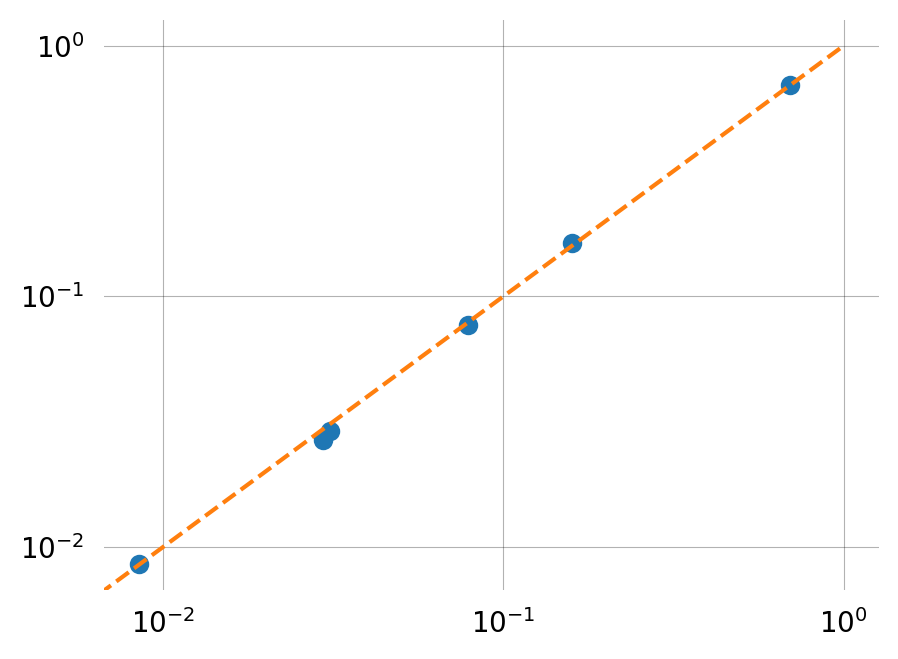

In [24]:
plt.plot([0, 1], [0, 1], ls='--', c='C1')
plt.scatter(pm.empirical_probs, pm.model_probs)
plt.xscale('log')
plt.yscale('log')

In [25]:
svgd_jp = joint_graph.svgd(
    observations,
    prior=pm.prior,
    fixed=[(1, mutation_rate)],
    optimizer=Adam(0.25),
)
svgd_jp.summary()
svgd_jp.plot_convergence()

ValueError: Sharding passed to jit does not match the sharding on the respective arg. Got jit sharding: NamedSharding(mesh=Mesh('batch': 16, axis_types=(Auto,)), spec=P('batch',), memory_kind=device),
arg sharding: NamedSharding(mesh=Mesh('batch': 16, axis_types=(Auto,)), spec=P(), memory_kind=device) for arg type: float64[16,3,1]

## Bayesian Inference with SVGD (Stein Variational Gradient Descent)

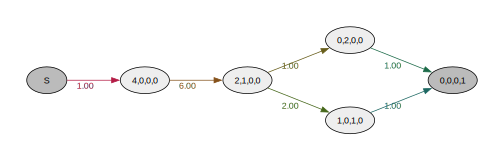

In [26]:
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent_1param)
graph.plot()

In [27]:
true_theta = [7]
graph.update_weights(true_theta)
nr_observations = 10000
observed_data = graph.sample(nr_observations)

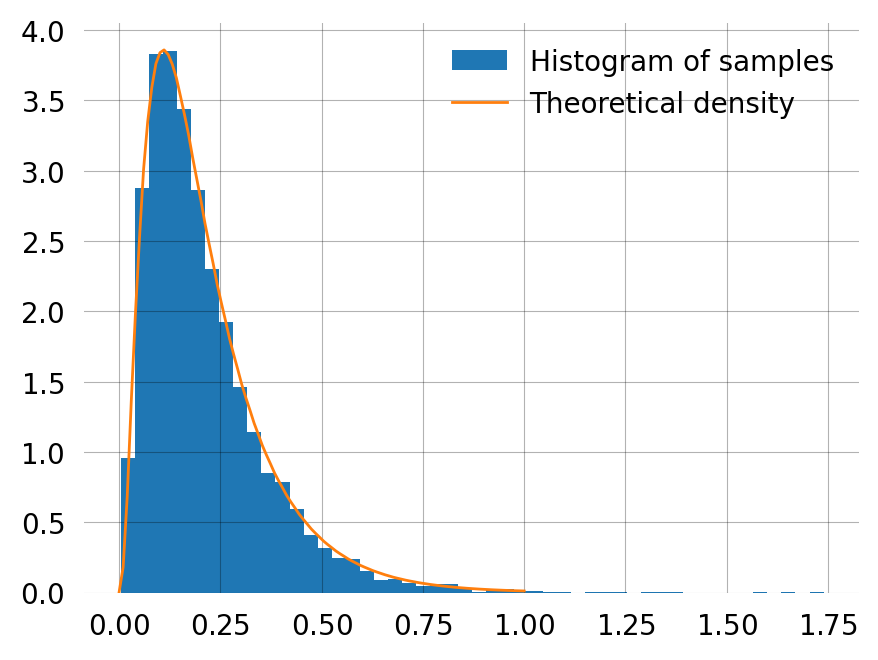

In [28]:
fig, ax = plt.subplots()
ax.hist(observed_data, density=True, bins=50, label='Histogram of samples')
x = np.linspace(0, 1, 100)
ax.plot(x, graph.pdf(x), color='C1', lw=1, label='Theoretical density')
ax.legend() ;

In [29]:
svgd = graph.svgd(observed_data, n_iterations=200)

ValueError: Sharding passed to jit does not match the sharding on the respective arg. Got jit sharding: NamedSharding(mesh=Mesh('batch': 16, axis_types=(Auto,)), spec=P('batch',), memory_kind=device),
arg sharding: NamedSharding(mesh=Mesh('batch': 16, axis_types=(Auto,)), spec=P(), memory_kind=device) for arg type: float64[16,2,1]

In [ ]:
svgd.learning_rate

In [ ]:
svgd.plot_trace();

In [ ]:
svgd.plot_ci(true_theta=true_theta) ;

## Prior

In [ ]:
svgd.prior.plot() ;

In [ ]:
GaussPrior(mean=svgd.prior.theta.item(), std=svgd.prior.std.item()).plot() ;

In [ ]:
prior = HalfCauchyPrior(ci=0.4, prob=0.8)
prior.plot();

In [ ]:
# prior = Prior(mean=5, std=2) 
prior = GaussPrior(ci=[2, 5])
prior.plot();

In [ ]:
svgd = graph.svgd(observed_data, 
                  prior=prior
                  )
svgd.plot_ci(true_theta=true_theta) ;

In [ ]:
svgd.analyze_trace()

In [ ]:
svgd = graph.svgd(observed_data, 
                  prior=prior, 
                  learning_rate=0.05
                  )
svgd.plot_ci(true_theta=true_theta)

In [ ]:
step_schedule = ExpStepSize(first_step=0.05, last_step=0.01, tau=30.0)
step_schedule.plot(100);

In [ ]:
svgd = graph.svgd(observed_data, 
                  prior=prior, 
                  learning_rate=step_schedule
                  )
svgd.plot_ci(true_theta=true_theta)

In [ ]:
svgd.plot_convergence() ;

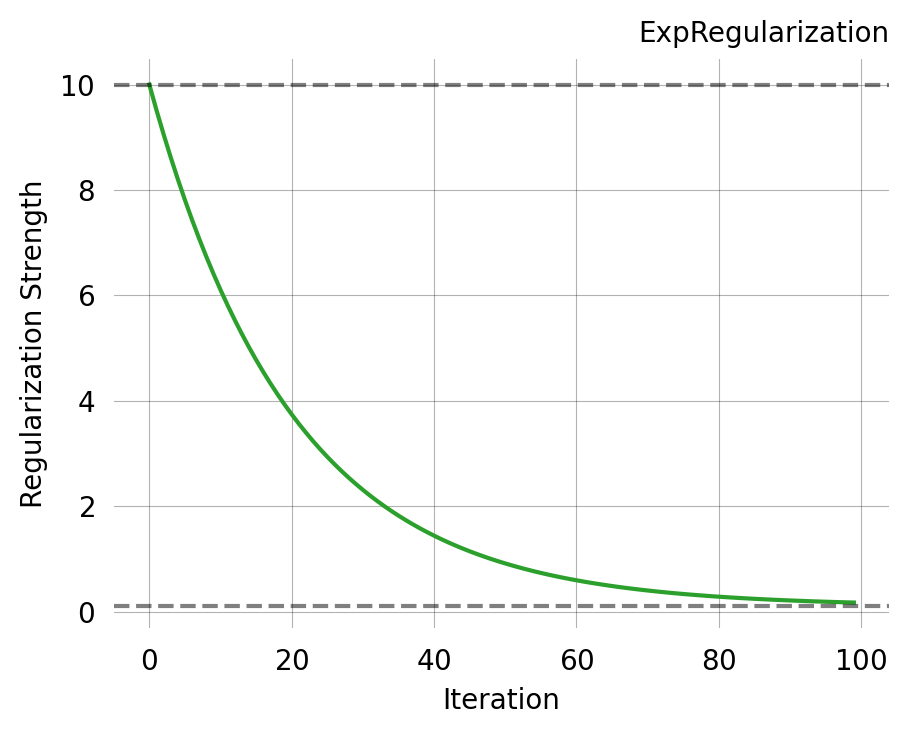

In [30]:
reg_schedule = ExpRegularization(first_reg=10.0, last_reg=0.1, tau=20.0)
reg_schedule.plot(100) ;

In [ ]:
svgd = graph.svgd(observed_data, 
                  prior=prior, 
                  learning_rate=step_schedule,
                  regularization=reg_schedule,
                  nr_moments=2
                  )
svgd.plot_ci(true_theta=true_theta)

### Posterior predictive checks

NameError: name 'svgd' is not defined

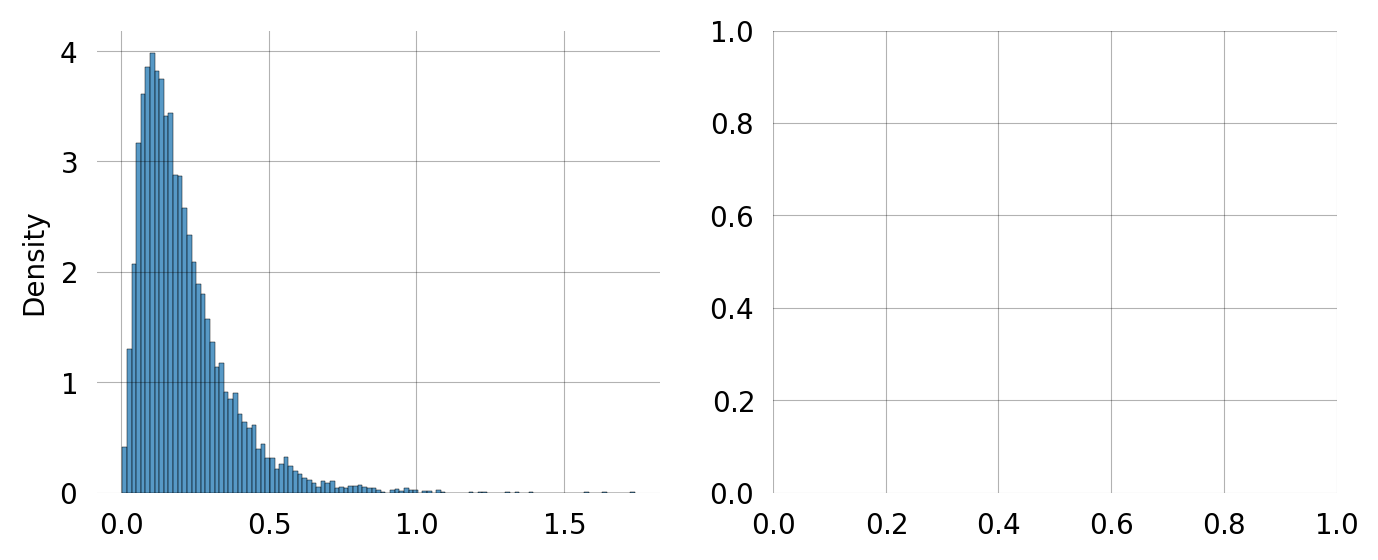

In [31]:
from scipy.stats import ecdf

# ECDF for observed data
res = ecdf(observed_data)
x, ecdf = res.cdf.quantiles, res.cdf.probabilities

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,3))
sns.histplot(observed_data,
             kde=False, stat='density', label='Data', ax=ax1)
graph.update_weights(svgd.get_results()['theta_mean'])
ax1.plot(x, graph.pdf(x), lw=1.5, c='C1', label='PDF')
ax1.set_xlabel('Reward (time)')
ax1.set_title('PDF')
ax1.legend()
ax2.plot(x, ecdf, lw=1.5, c='C0', label='ECDF')
ax2.plot(x, graph.cdf(x), lw=1.5, c='C1', label='CDF')
ax2.set_xlabel('Reward (time)')
ax2.set_title('CDF')
ax2.legend() 
ax3 = ax2.twinx()
ax3.plot(x, graph.cdf(x)-ecdf, lw=0.5, c='C2', 
    alpha=0.5,label='CDF-ECDF')
ax3.grid(False)
ax3.set_ylabel('CDF - ECDF', color='C2')
ax3.tick_params(axis='y', colors='C2')
plt.tight_layout()

## Two population model

Multi-parameter inference

In [32]:
from phasic import (
    Graph, with_ipv, set_log_level,
    StateIndexer, Property,
    GaussPrior, HalfCauchyPrior, ExpStepSize, ExpRegularization, 
    clear_caches, clear_jax_cache, clear_model_cache,
) # ALWAYS import phasic first to set jax backend correctly
import numpy as np
import jax.numpy as jnp
import pandas as pd
from typing import Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from tqdm.auto import tqdm
from typing import Optional, Callable
from functools import partial
from itertools import combinations, combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)

from vscodenb import set_vscode_theme
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

set_log_level('WARNING')

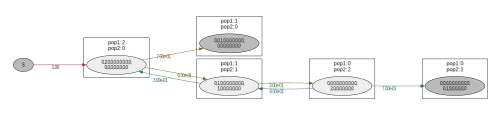

In [33]:
nr_samples = 2

indexer = StateIndexer(
    descendants=[
    Property('pop1', min_value=0, max_value=nr_samples),
    Property('pop2', min_value=0, max_value=nr_samples),
    Property('in_pop', min_value=1, max_value=2),
])

initial = [0] * indexer.state_length

# set initial state with all lineages having one descendant at both loci
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial)
def two_island(state):
    transitions = []

    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions
    
    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)

        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            
            if props_j.in_pop != props_i.in_pop:
                continue

            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 

            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            des_pop1 = props_i.pop1 + props_j.pop1
            des_pop2 = props_i.pop2 + props_j.pop2
            if des_pop1 <= nr_samples and des_pop2 <= nr_samples:
                k = indexer.descendants.props_to_index(
                    pop1=des_pop1, 
                    pop2=des_pop2, 
                    in_pop=props_i.in_pop
                    )
                child[k] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])

        if state[i] > 0:
            child = state.copy()
            other_pop = 2 if props_i.in_pop == 1 else 1
            child = state.copy()
            child[i] -= 1
            k = indexer.descendants.props_to_index(
                pop1=props_i.pop1, 
                pop2=props_i.pop2, 
                in_pop=other_pop
                )
            child[k] += 1

            transitions.append([child, [0, state[i]]])

    return transitions

graph = Graph(two_island)   

true_theta = [0.7, 0.3]
graph.update_weights(true_theta)

def label(state):
    nr_pop1 = sum([state[i] * bool(indexer.index_to_props(i).descendants.in_pop == 1) for i in indexer])
    nr_pop2 = sum([state[i] * bool(indexer.index_to_props(i).descendants.in_pop == 2) for i in indexer])
    return f"pop1: {nr_pop1}\npop2: {nr_pop2}"

graph.plot(rankdir='LR', nodesep=0.3, ranksep=2,
                      wrap=10, 
                    #   label_fmt=False, 
                      by_state=label)

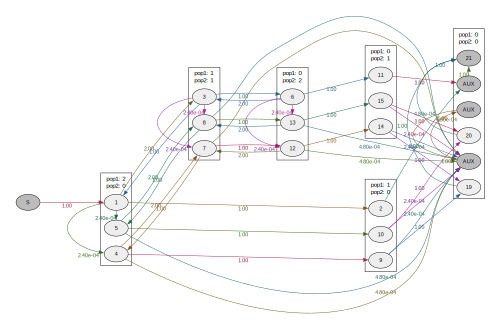

In [34]:
mutation_rate = 1.2e-4
joint_prob_graph = graph.joint_prob_graph(indexer, 
                                          reward_only=['pop1', 'pop2'],
                                          reward_limit=1,
                                          tot_reward_limit=1, 
                                          mutation_rate=mutation_rate)

joint_prob_graph.plot(rankdir='LR', nodesep=0.3, ranksep=2,
                      wrap=10, label_fmt=False, by_state=label)

In [35]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table

,pop1_0,pop1_1,pop1_2,pop2_0,pop2_1,pop2_2,prob
t_vertex_index,,,,,,,
18,0,0,0,0,0,0,0.999041
19,0,1,0,0,0,0,0.000479
20,0,0,0,1,0,0,0.000479


In [36]:
observations = graph.sample(1000)

In [37]:
svgd = graph.svgd(observations, 
                #   n_particles=40, n_iterations=100
                  )
svgd.summary()

ValueError: Sharding passed to jit does not match the sharding on the respective arg. Got jit sharding: NamedSharding(mesh=Mesh('batch': 16, axis_types=(Auto,)), spec=P('batch',), memory_kind=device),
arg sharding: NamedSharding(mesh=Mesh('batch': 16, axis_types=(Auto,)), spec=P(), memory_kind=device) for arg type: float64[16,3,2]

In [ ]:
svgd.plot_convergence()

In [ ]:
svgd.plot_ci()

In [ ]:
svgd.plot_trace()

In [ ]:
svgd.plot_hdr()

In [ ]:
svgd.plot_pairwise(true_theta=true_theta)

## Joint probability inference

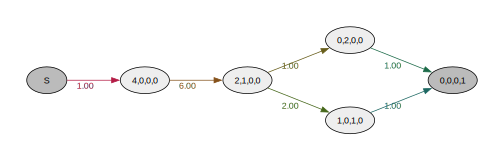

In [38]:
nr_samples = 4
indexer = StateIndexer(
    lineage=[
        Property('descendants', min_value=1, max_value=nr_samples),
    ]
)

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i, j in all_pairs(indexer.lineage):
        p1 = indexer.lineage.index_to_props(i)
        p2 = indexer.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue 
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        descendants = p1.descendants + p2.descendants
        k = indexer.lineage.props_to_index(descendants=descendants)
        new[k] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent_1param)
graph.plot()

In [39]:
mutation_rate = 1
joint_prob_graph = graph.joint_prob_graph(indexer, tot_reward_limit=2, mutation_rate=mutation_rate)
joint_prob_graph.vertices_length()

39

In [40]:
joint_prob_graph.param_length()

2

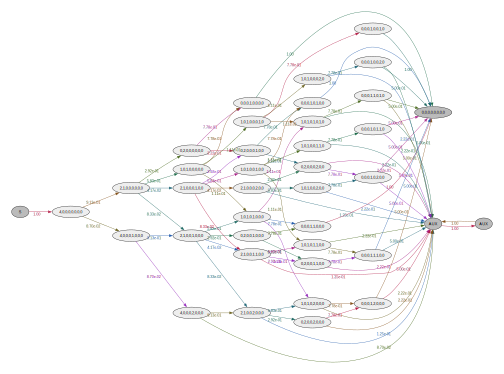

In [41]:
true_theta = [7, mutation_rate]
joint_prob_graph.update_weights(true_theta)
joint_prob_graph.plot(nodesep=0.3)

In [42]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table

,descendants_1,descendants_2,descendants_3,descendants_4,prob
t_vertex_index,,,,,
9,0,0,0,0,0.621377
18,0,1,0,0,0.071919
20,1,0,0,0,0.151842
23,0,0,1,0,0.046028
30,0,2,0,0,0.013225
31,2,0,0,0,0.026469
32,1,0,1,0,0.018067
33,0,0,2,0,0.005114
34,1,1,0,0,0.016322


In [43]:
(1 - joint_prob_table['prob'].sum()).item()

0.02771995193202048

## Test data

In [49]:
def sample_joint_observations(joint_prob_graph, theta, nr_observations=1000):
    joint_prob_graph.update_weights(theta) 
    joint_prob_table = joint_prob_graph.joint_prob_table()
    p = joint_prob_table['prob'] / joint_prob_table['prob'].sum()
    p = p.to_numpy()
    sample = np.random.choice(joint_prob_table.index.values, nr_observations, p=p)
    observations = joint_prob_table.loc[sample, joint_prob_table.columns[:-1]].to_numpy().tolist()
    return observations

In [45]:
true_theta = [7, mutation_rate] # coalescent rate and mutation rate
observations = sample_joint_observations(joint_prob_graph, true_theta, nr_observations=1000)
observations[:5]

[[1, 0, 0, 0], [0, 0, 0, 0], [1, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]

In [50]:
modelled_obs = joint.loc[sample, joint.columns[:-1]].to_numpy().tolist()
allowed_observations = set(tuple(x) for x in modelled_obs)
observations = [o for o in observations if tuple(o) in allowed_observations]
observations = np.array(observations)
observations

NameError: name 'joint' is not defined

In [ ]:
svgd = joint_prob_graph.svgd(
    observations, 
    fixed=[(1, mutation_rate)],  # Fix theta[1] (mutation) at actual mutation_rate value
    n_iterations=200,
    # prior=GaussPrior(ci=[1, 5]),
    # optimizer=Adamelia(learning_rate=0.2),
    learning_rate = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0),
    # regularization=ExpRegularization(first_reg=10.0, last_reg=0.1, tau=20.0),
    )

In [ ]:
svgd.summary(ci_method='hpd', ci_level=0.95)

In [ ]:
svgd.plot_ci(ci_method='hpd')

In [ ]:
svgd.plot_convergence()

In [ ]:
svgd.plot_trace()

## ARG

In [51]:
# create state space for two-locus model
nr_samples = 3
indexer = StateIndexer(
    descendants=[
        Property('loc1', min_value=0, max_value=nr_samples),
        Property('loc2', min_value=0, max_value=nr_samples)
    ]
)

# initial state with all lineages having one descendant at both loci
initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(loc1=1, loc2=1)] = nr_samples

@with_ipv(initial)
def two_locus_arg_2param(state, indexer=None):

    transitions = []
    if state.sum() <= 1: return transitions

    for i in range(indexer.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)

        for j in range(i, indexer.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            des_loc1 = props_i.loc1 + props_j.loc1
            des_loc2 = props_i.loc2 + props_j.loc2
            if des_loc1 <= nr_samples and des_loc2 <= nr_samples:
                child[indexer.descendants.props_to_index(loc1=des_loc1, loc2=des_loc2)] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])

        if state[i] > 0 and props_i.loc1 > 0 and props_i.loc2 > 0:
            child = state.copy()
            child[i] -= 1
            child[indexer.descendants.props_to_index(loc1=0, loc2=props_i.loc2)] += 1
            child[indexer.descendants.props_to_index(loc1=props_i.loc1, loc2=0)] += 1
            transitions.append([child, [0, state[i]]])
            # transitions.append([child, [0, 1]])

    return transitions

In [52]:
graph = Graph(two_locus_arg_2param, indexer=indexer, 
            #   graph_cache=True, 
            #   cache_trace=True
            )
graph.vertices_length()

32

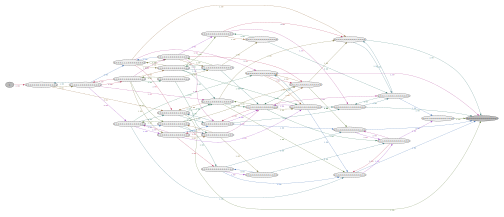

In [53]:
graph.plot(nodesep=0.5, wrap=False)

In [54]:
mutation_rate = 1
joint_prob_graph = graph.joint_prob_graph(indexer,
                                           reward_only=['loc1', 'loc2'],       
                                          reward_limit=1,                                   
                               tot_reward_limit=2, 
                               mutation_rate=mutation_rate
                               )

In [55]:
true_theta = [10, 1, mutation_rate] # coalescent, recombination, and mutation rate
observations = sample_joint_observations(joint_prob_graph, true_theta, nr_observations=1000)
observations[:5]

[[0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 1, 0, 0, 0, 1, 0],
 [0, 0, 1, 0, 0, 0, 0, 0],
 [0, 1, 0, 0, 0, 0, 0, 0],
 [0, 0, 1, 0, 0, 0, 0, 0]]

In [56]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table.head()

,loc1_0,loc1_1,loc1_2,loc1_3,loc2_0,loc2_1,loc2_2,loc2_3,prob
t_vertex_index,,,,,,,,,
6,0,0,0,0,0,0,0,0,0.576233
38,0,1,0,0,0,0,0,0,0.088287
42,0,0,1,0,0,0,0,0,0.040607
45,0,0,0,0,0,1,0,0,0.088287
47,0,0,0,0,0,0,1,0,0.040607


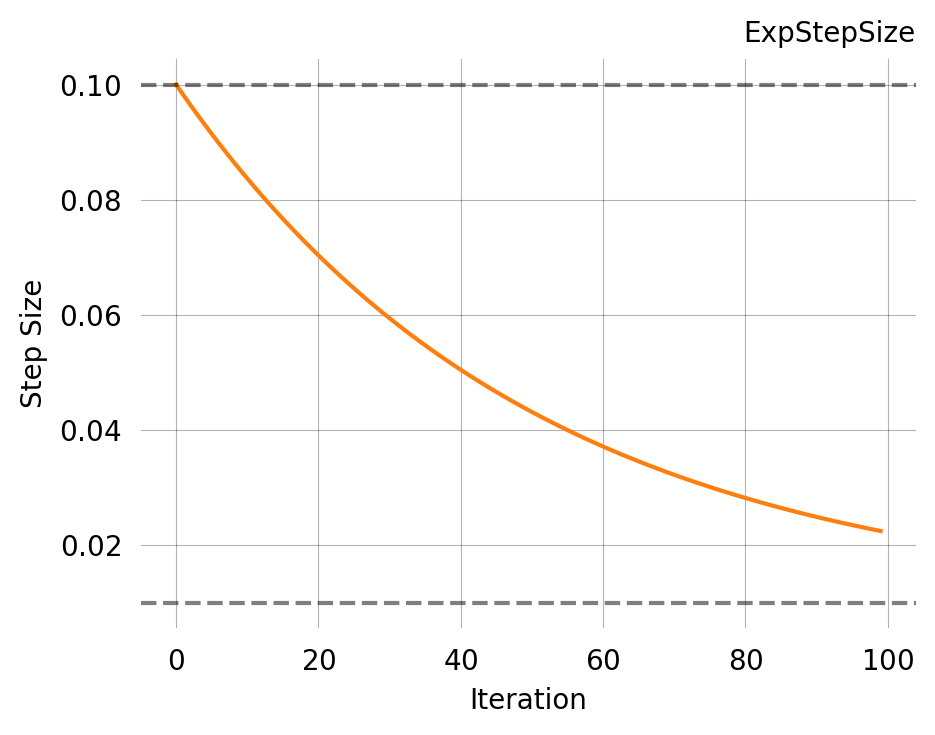

In [57]:
ExpStepSize(first_step=0.1, last_step=0.01, tau=50.0).plot(100) ;

In [58]:
%%monitor

svgd = joint_prob_graph.svgd(
    observed_data=observations, 
    fixed=[(2, mutation_rate)],
    n_iterations=100,
    n_particles=200,
    prior=[
        GaussPrior(ci=[5, 25]),
        GaussPrior(ci=[0, 3]),
        None
    ],
    learning_rate=ExpStepSize(first_step=0.1, last_step=0.01, tau=50.0),
    )
svgd.summary()

ValueError: Sharding passed to jit does not match the sharding on the respective arg. Got jit sharding: NamedSharding(mesh=Mesh('batch': 16, axis_types=(Auto,)), spec=P('batch',), memory_kind=device),
arg sharding: NamedSharding(mesh=Mesh('batch': 16, axis_types=(Auto,)), spec=P(), memory_kind=device) for arg type: float64[16,13,2]

In [ ]:
svgd.plot_ci(ci_method='hpd')

In [ ]:
svgd.plot_convergence() ;

In [ ]:
svgd.plot_trace()

In [ ]:
svgd.map_estimate_from_particles()

In [ ]:
svgd.plot_hdr()

In [ ]:
svgd.plot_hdr(hexgrid=False) ;

In [ ]:
svgd.plot_pairwise(true_theta=true_theta) ;

In [ ]:
svgd.animate_pairwise(true_theta=true_theta)